# 🏨 Hotel Booking Cancellation Prediction Using Ensemble Learning

## Objective

This project aims to predict whether a hotel booking will be cancelled using Machine Learning.

Three models will be compared:

- Decision Tree
- Random Forest
- XGBoost

The project includes:

- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- Hyperparameter Tuning
- Model Comparison

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:\Hotel-Booking-Cancellation-Using-Ensemble-Learning\Hotel-Booking-Cancellation-Using-Ensemble-Learning\data\hotel_bookings.csv")

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.shape

(119390, 32)

In [5]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [8]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

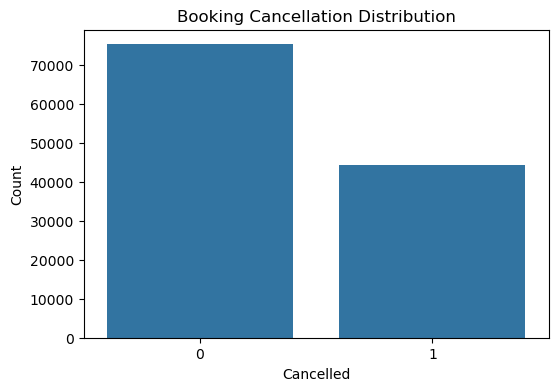

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="is_canceled", data=df)
plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancelled")
plt.ylabel("Count")
plt.show()

## Observation

The distribution of cancelled and non-cancelled bookings was visualized to understand whether the dataset is balanced or imbalanced.

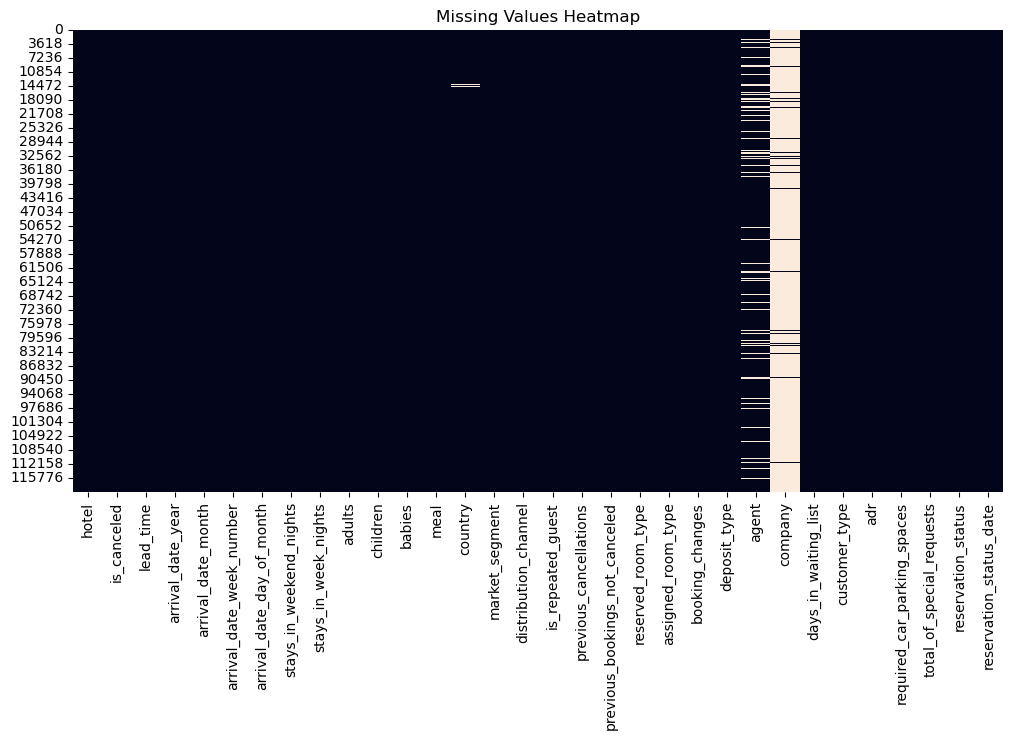

In [10]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

## Observation

The heatmap highlights columns containing missing values, which will guide the preprocessing stage.

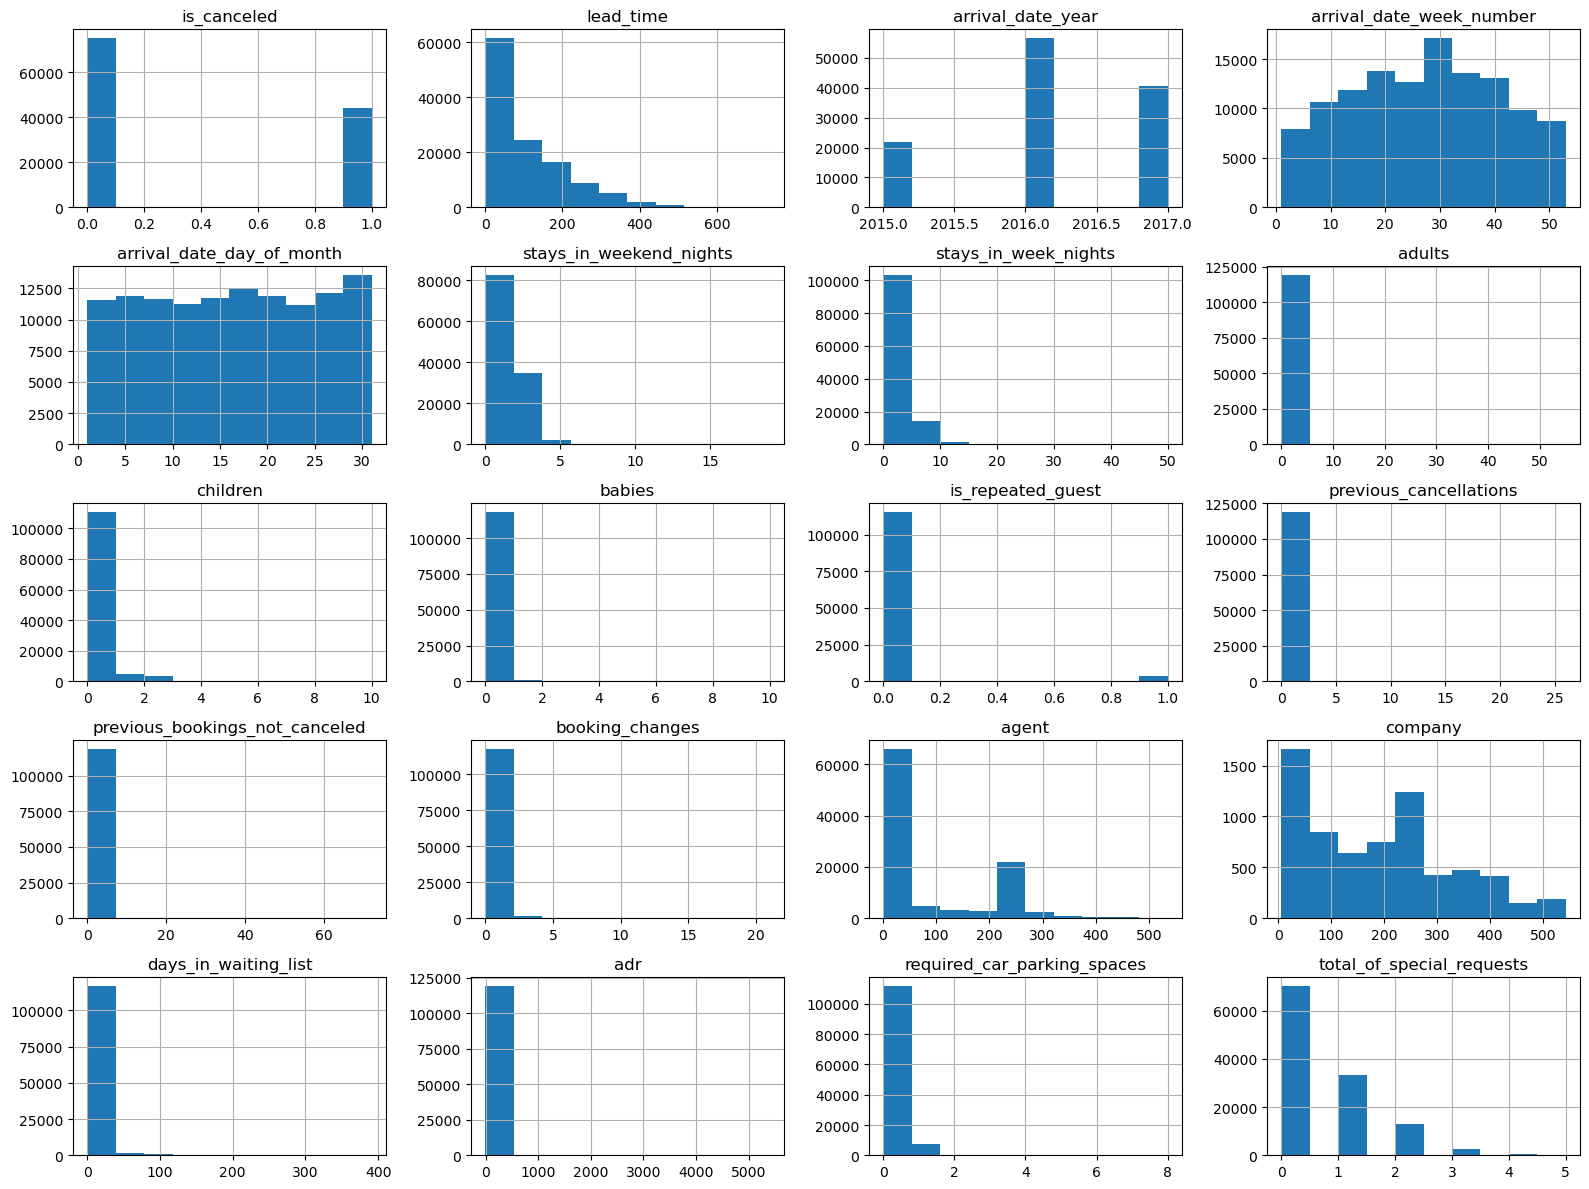

In [11]:
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns

df[numerical_columns].hist(figsize=(16,12))
plt.tight_layout()
plt.show()

## Observation

The numerical feature distributions were examined to identify skewness, outliers, and unusual value ranges.

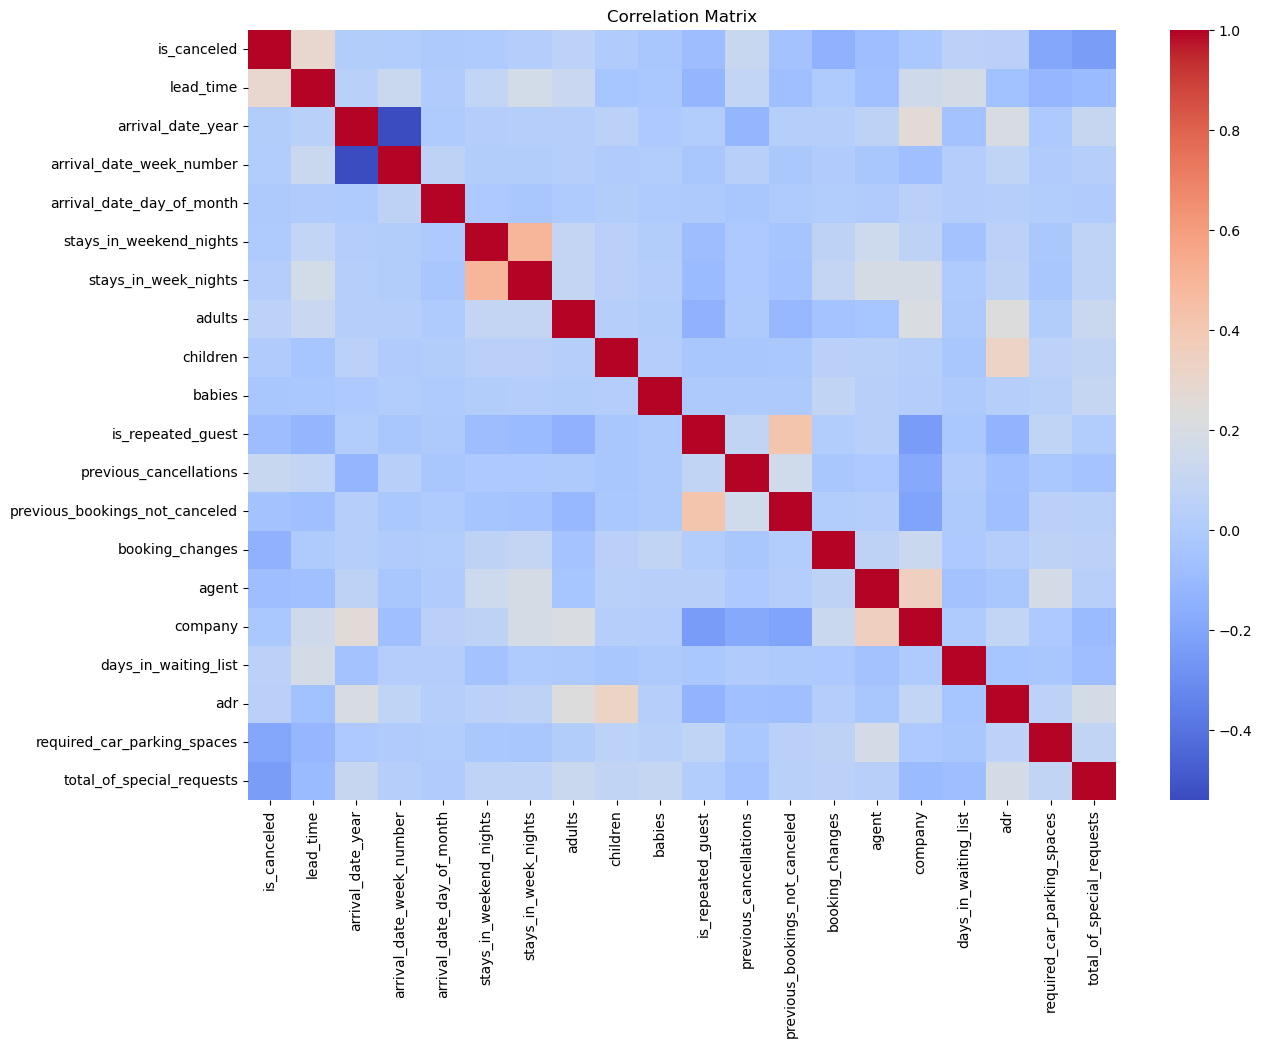

In [12]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df[numerical_columns].corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## Observation

The correlation matrix was used to identify relationships among numerical features and detect highly correlated variables.

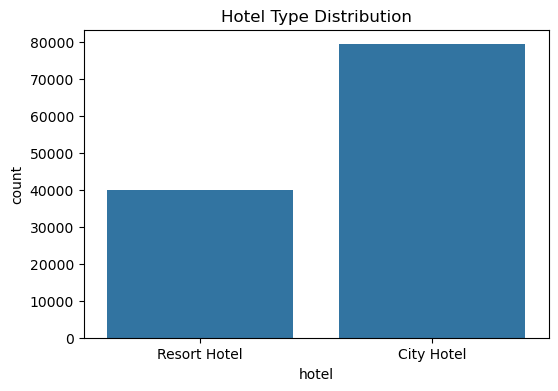

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="hotel", data=df)
plt.title("Hotel Type Distribution")
plt.show()

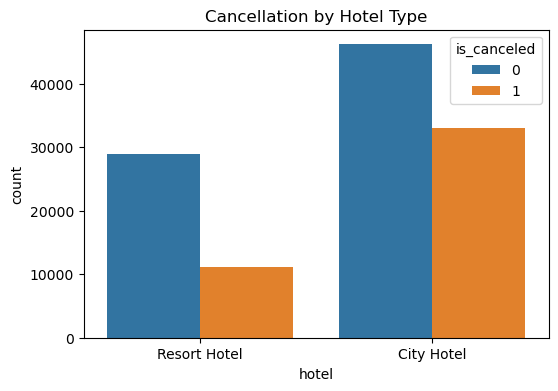

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="hotel",
    hue="is_canceled",
    data=df
)

plt.title("Cancellation by Hotel Type")
plt.show()

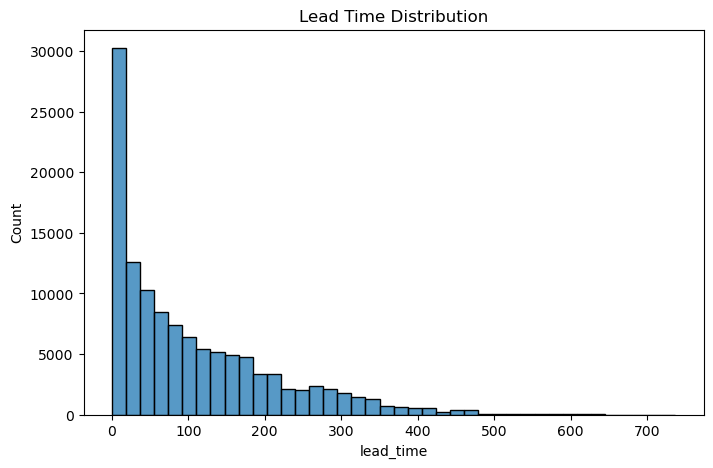

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["lead_time"],
    bins=40
)

plt.title("Lead Time Distribution")
plt.show()

## Overall EDA Summary

- Explored the target variable distribution.
- Identified missing values.
- Examined numerical feature distributions.
- Analyzed correlations among numerical features.
- Compared hotel types.
- Observed booking cancellation trends.
- Studied booking lead time.

These observations will guide data preprocessing and feature engineering in the next phase.

In [16]:
df.duplicated().sum()

np.int64(31994)

In [17]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
hotel                                  0
previous_cancellations                 0
days_in_waiting_list                   0
customer_type                          0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
reservation_status                     0
previous_bookings_not_canceled         0
is_repeated_guest                      0
is_canceled                            0
distribution_channel                   0
market_segment                         0
meal                                   0
babies                                 0
adults                                 0
stays_in_week_ni

In [18]:
missing = (df.isnull().sum() / len(df)) * 100
missing.sort_values(ascending=False)

company                           94.306893
agent                             13.686238
country                            0.408744
children                           0.003350
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                       0.000000
hotel                              0.000000
previous_cancellations             0.000000
days_in_waiting_list               0.000000
customer_type                      0.000000
adr                                0.000000
required_car_parking_spaces        0.000000
total_of_special_requests          0.000000
reservation_status                 0.000000
previous_bookings_not_canceled     0.000000
is_repeated_guest                  0.000000
is_canceled                        0.000000
distribution_channel               0.000000
market_segment                     0.000000
meal                               0.000000
babies                          

In [19]:
print("Shape before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (119390, 32)
Shape after removing duplicates: (87396, 32)


In [20]:
df = df.drop(columns=["company"])

In [21]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

## Data Cleaning - Part 1

- Duplicate rows were removed to avoid bias during model training.
- The company column was dropped because it contained approximately 94% missing values, making it unsuitable for reliable analysis.

In [22]:
df["children"] = df["children"].fillna(df["children"].median())

In [23]:
df["country"] = df["country"].fillna(df["country"].mode()[0])

In [24]:
df["agent"] = df["agent"].fillna(df["agent"].mode()[0])

In [25]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

## Data Cleaning - Part 2

Missing values were handled based on the data type of each feature.

- children was filled using the median because it is a numerical feature.
- country was filled using the mode because it is a categorical feature.
- agent was filled using the mode because it represents an identifier rather than a continuous numerical value.

After imputation, the dataset contained no missing values in the remaining columns.

# Feature Engineering

In [26]:
hotel_df = df.copy()

In [27]:
hotel_df["total_guests"] = (
    hotel_df["adults"]
    + hotel_df["children"]
    + hotel_df["babies"]
)

In [28]:
hotel_df["total_nights"] = (
    hotel_df["stays_in_weekend_nights"]
    + hotel_df["stays_in_week_nights"]
)

In [29]:
hotel_df["is_family"] = (
    (hotel_df["children"] > 0)
    | (hotel_df["babies"] > 0)
).astype(int)

In [30]:
hotel_df["previous_customer"] = hotel_df["is_repeated_guest"]

In [31]:
hotel_df["high_special_requests"] = (
    hotel_df["total_of_special_requests"] >= 2
).astype(int)

In [32]:
hotel_df[
    [
        "total_guests",
        "total_nights",
        "is_family",
        "previous_customer",
        "high_special_requests"
    ]
].head()

,total_guests,total_nights,is_family,previous_customer,high_special_requests
0,2.0,0,0,0,0
1,2.0,0,0,0,0
2,1.0,1,0,0,0
3,1.0,1,0,0,0
4,2.0,2,0,0,0


In [33]:
hotel_df.drop(
    columns=[
        "reservation_status",
        "reservation_status_date"
    ],
    inplace=True
)

In [34]:
hotel_df.select_dtypes(include="object").columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object')

In [35]:
hotel_df = pd.get_dummies(
    hotel_df,
    drop_first=True
)

print(hotel_df.shape)
hotel_df.head()

(87396, 252)


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,737,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,7,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
3,0,13,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
4,0,14,2015,27,1,0,2,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False


In [36]:
# Estimated Total Booking Cost
hotel_df["estimated_total_cost"] = (
    hotel_df["adr"] * hotel_df["total_nights"]
)

# Cost Per Guest
hotel_df["cost_per_guest"] = (
    hotel_df["adr"] / hotel_df["total_guests"].replace(0, 1)
)

# Booking Changes Per Night
hotel_df["changes_per_night"] = (
    hotel_df["booking_changes"] /
    (hotel_df["total_nights"] + 1)
)

# Cancellation Risk Score
hotel_df["risk_score"] = (
    hotel_df["lead_time"] *
    hotel_df["previous_cancellations"]
)

In [37]:
hotel_df["is_couple"] = (
    (hotel_df["adults"] == 2) &
    (hotel_df["children"] == 0) &
    (hotel_df["babies"] == 0)
).astype(int)

In [38]:
hotel_df["estimated_booking_value"] = (
    hotel_df["adr"] *
    hotel_df["total_nights"]
)

In [39]:
hotel_df["cost_per_guest"] = (
    hotel_df["adr"] /
    hotel_df["total_guests"].replace(0,1)
)

In [40]:
hotel_df["long_stay"] = (
    hotel_df["total_nights"] >= 7
).astype(int)

In [41]:
hotel_df["is_couple"] = (
    (hotel_df["adults"] == 2) &
    (hotel_df["children"] == 0) &
    (hotel_df["babies"] == 0)
).astype(int)

In [42]:
hotel_df["risk_score"] = (
    hotel_df["lead_time"] *
    hotel_df["previous_cancellations"]
)

In [43]:
new_features = [
    "estimated_booking_value",
    "cost_per_guest",
    "long_stay",
    "is_couple",
    "risk_score"
]

hotel_df[new_features].head()

,estimated_booking_value,cost_per_guest,long_stay,is_couple,risk_score
0,0.0,0.0,0,1,0
1,0.0,0.0,0,1,0
2,75.0,75.0,0,0,0
3,75.0,75.0,0,0,0
4,196.0,49.0,0,1,0


In [44]:
# Features
X = hotel_df.drop("is_canceled", axis=1)

# Target
y = hotel_df["is_canceled"]

print("Features :", X.shape)
print("Target :", y.shape)

Features : (87396, 258)
Target : (87396,)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [47]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [48]:
y_pred = lr_model.predict(X_test_scaled)

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7969
Precision: 0.6833
Recall   : 0.4864
F1 Score : 0.5683


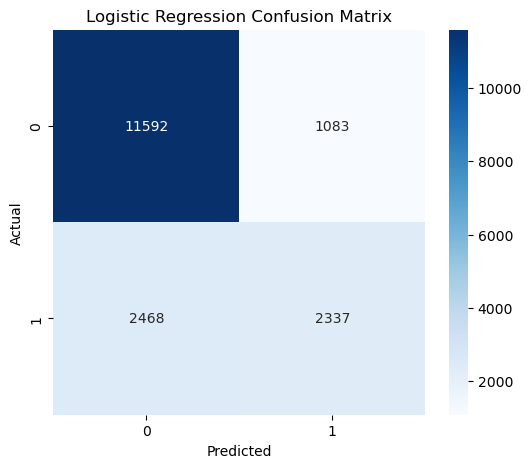

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [51]:
from sklearn.tree import DecisionTreeClassifier

In [52]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [53]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:
y_pred_dt = dt_model.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Accuracy : 0.792162471395881
Precision: 0.6193482688391039
Recall   : 0.632882414151925
F1 Score : 0.6260422027792074


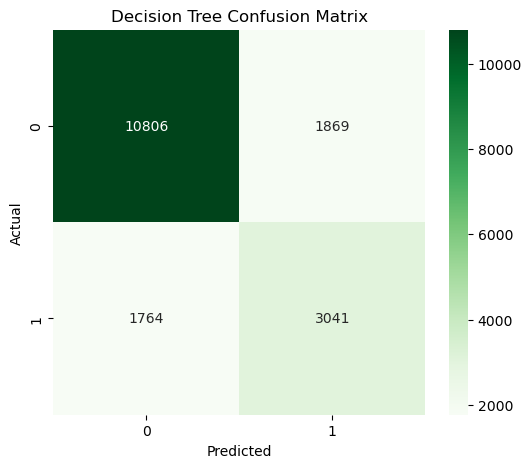

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🌳 Decision Tree Model

## Objective

Train a Decision Tree classifier on the hotel booking dataset and compare its performance with the Logistic Regression baseline.

## Why Decision Tree?

Unlike Logistic Regression, which assumes a linear relationship, Decision Trees can learn complex and non-linear patterns by recursively splitting the data based on feature values.

## Evaluation Metrics

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

## Observation

The Decision Tree significantly improved Recall and F1 Score compared to Logistic Regression, making it more suitable for identifying cancelled bookings. Although Precision decreased slightly, the higher Recall aligns better with the project's business objective of detecting as many cancellations as possible.

## 📊 Logistic Regression vs Decision Tree

| Metric | Logistic Regression | Decision Tree |
|---------|--------------------:|--------------:|
| Accuracy | **79.69%** | **79.13%** |
| Precision | **68.33%** | **61.93%** |
| Recall | **48.64%** | **63.29%** |
| F1 Score | **56.83%** | **62.60%** |

### Conclusion

- Logistic Regression achieved slightly higher Accuracy and Precision.
- Decision Tree achieved a significantly higher Recall and F1 Score.
- Since the project focuses on identifying cancelled bookings, Decision Tree currently provides a better balance between business requirements and model performance.

In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [59]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
y_pred_rf = rf_model.predict(X_test)

In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.840675057208238
Precision: 0.767478813559322
Recall   : 0.6031217481789802
F1 Score : 0.6754457522433283


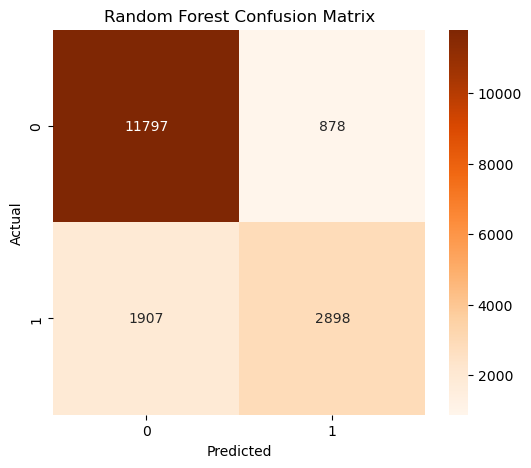

In [62]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [63]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,lead_time,0.097922
256,estimated_booking_value,0.054676
251,estimated_total_cost,0.053982
15,adr,0.053173
252,cost_per_guest,0.051246
3,arrival_date_day_of_month,0.047841
2,arrival_date_week_number,0.045554
17,total_of_special_requests,0.044154
173,country_PRT,0.041936
13,agent,0.036866


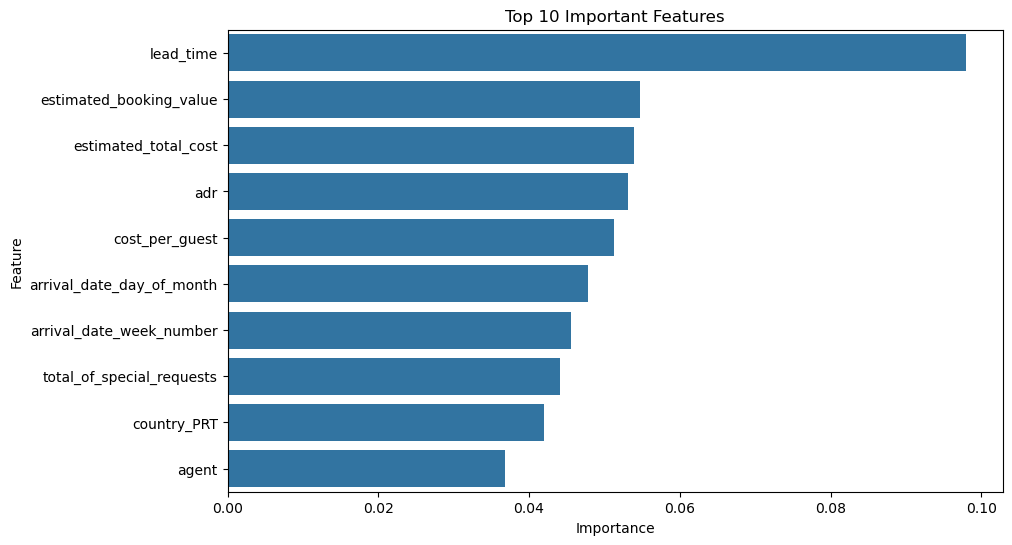

In [64]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

## Observation
Several engineered features, including estimated booking value, estimated total cost, and cost per guest, ranked among the most important predictors in the Random Forest model, indicating that feature engineering improved the model's ability to capture meaningful booking patterns.

# 🌲 Random Forest Model

## Objective

Train a Random Forest classifier to improve generalization by combining multiple Decision Trees.

## Why Random Forest?

Random Forest reduces overfitting by training multiple Decision Trees on different bootstrap samples and combining their predictions using majority voting.

## Evaluation

The Random Forest model achieved the highest Accuracy, Precision, and F1 Score among all models tested so far.

## Feature Importance

The model identified **lead_time** as the most influential feature. Interestingly, several engineered features such as **estimated_booking_value**, **estimated_total_cost**, and **cost_per_guest** also ranked among the top predictors, demonstrating the effectiveness of our feature engineering process.

## Conclusion

Random Forest currently provides the best overall balance between Precision and Recall, making it the strongest candidate for hotel booking cancellation prediction at this stage.

# ⚡ XGBoost Classifier

## Objective

Train an XGBoost classifier to improve hotel booking cancellation prediction by using gradient boosting.

## Why XGBoost?

XGBoost is an ensemble learning algorithm that builds multiple decision trees sequentially. Each new tree learns from the mistakes made by the previous trees, helping improve prediction performance and reduce errors.

## Evaluation Metrics

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Feature Importance


In [65]:
from xgboost import XGBClassifier

In [66]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

In [67]:
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [68]:
y_pred_xgb = xgb_model.predict(X_test)

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

Accuracy : 0.8419908466819221
Precision: 0.7527839643652561
Recall   : 0.6330905306971905
F1 Score : 0.6877684829301379


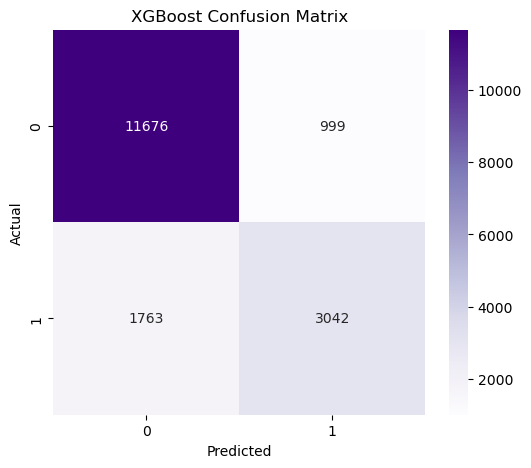

In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [71]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
220,market_segment_Online TA,0.092000
16,required_car_parking_spaces,0.091261
173,country_PRT,0.070609
17,total_of_special_requests,0.050303
217,market_segment_Direct,0.040662
228,reserved_room_type_D,0.038782
246,deposit_type_Non Refund,0.037021
249,customer_type_Transient,0.029109
13,agent,0.026951
0,lead_time,0.025149


## 📊 XGBoost Results

| Metric | Value |
|---------|-------|
| Accuracy | **84.20%** |
| Precision | **75.27%** |
| Recall | **63.31%** |
| F1 Score | **68.78%** |

### Observation

- XGBoost achieved the highest Accuracy among all evaluated models.
- The Recall improved over Logistic Regression and slightly surpassed the Decision Tree.
- The model maintained a strong Precision while improving Recall, resulting in the highest F1 Score.
- Overall, XGBoost provided the best balance between correctly identifying cancelled bookings and minimizing false predictions.

### Conclusion

Among all the evaluated models, XGBoost achieved the best overall performance and is selected as the final model for this project.

# 🏆 Final Model Comparison

| Model | Accuracy | Precision | Recall | F1 Score |
|--------|----------:|----------:|--------:|----------:|
| Logistic Regression | 79.69% | 68.33% | 48.64% | 56.83% |
| Decision Tree | 79.13% | 61.93% | **63.29%** | 62.60% |
| Random Forest | 84.07% | **76.75%** | 60.31% | 67.54% |
| **XGBoost** | **84.20%** | 75.27% | **63.31%** | **68.78%** |

## Performance Summary

- Logistic Regression served as the baseline model.
- Decision Tree significantly improved Recall by capturing complex non-linear patterns.
- Random Forest achieved the highest Precision while maintaining strong overall performance.
- XGBoost achieved the highest Accuracy, Recall, and F1 Score, making it the best-performing model for this dataset.

## Selected Model

**XGBoost** is selected as the final model because it provides the best balance between Accuracy, Precision, Recall, and F1 Score, making it the most suitable model for predicting hotel booking cancellations.

# 📈 Model Explainability using SHAP

## Objective

Although XGBoost provides excellent predictive performance, it is considered a complex ensemble model. To improve model interpretability, SHAP (SHapley Additive exPlanations) is used to understand how each feature contributes to the model's predictions.

## Why SHAP?

SHAP assigns an importance value to every feature for every prediction based on cooperative game theory.

It helps answer questions such as:

- Which features are most influential?
- How does each feature affect the prediction?
- Why did the model make a particular prediction?

Using SHAP improves model transparency and makes the results easier to explain to stakeholders.

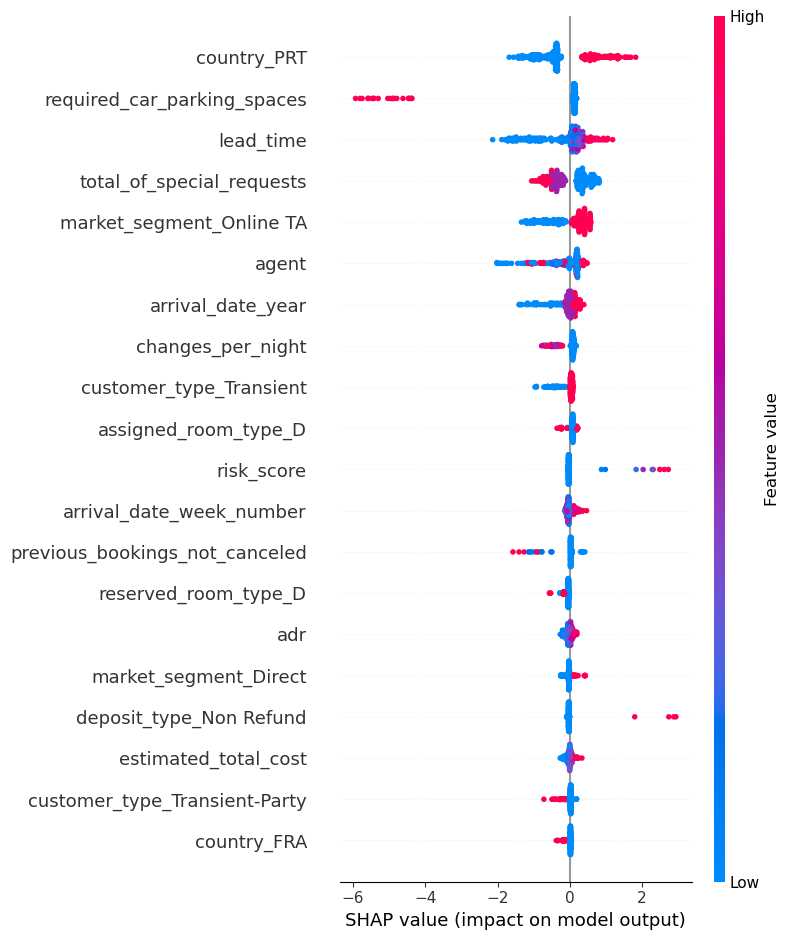

In [72]:
import shap

sample = X_test.sample(300, random_state=42)

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample)

## 📊 SHAP Summary Analysis

The SHAP summary plot visualizes the impact of each feature on the model's predictions.

### Key Observations

- **country_PRT** is one of the most influential features affecting booking cancellation predictions.
- **required_car_parking_spaces** strongly influences the prediction, where bookings requiring parking generally reduce the likelihood of cancellation.
- **lead_time** has a significant impact, with larger lead times generally increasing the probability of cancellation.
- **total_of_special_requests** also contributes meaningfully, indicating that customers with more special requests often exhibit different booking behavior.
- Market segment, customer type, room type, and deposit type also play important roles in determining booking cancellations.

### Conclusion

The SHAP analysis confirms that the XGBoost model makes predictions based on meaningful business-related features rather than random patterns. It improves the interpretability of the model and provides valuable insights into the factors influencing hotel booking cancellations.

### SHAP Explainability

SHAP (SHapley Additive Explanations) was used to interpret the predictions made by the XGBoost model.

The SHAP summary plot revealed that **country_PRT**, **required_car_parking_spaces**, **lead_time**, and **total_of_special_requests** were among the most influential features affecting hotel booking cancellation predictions.

Additionally, engineered features such as **changes_per_night** and **risk_score** appeared among the important contributors, demonstrating that the feature engineering process successfully captured meaningful booking behavior.

Overall, SHAP improved the transparency of the model by providing clear insights into how different features influenced individual predictions.

# 🎯 Project Conclusion

In this project, multiple machine learning algorithms were developed and evaluated to predict hotel booking cancellations.

The workflow included data cleaning, exploratory data analysis, feature engineering, encoding, model training, evaluation, and feature importance analysis.

Business-driven feature engineering played an important role in improving model performance by creating meaningful features from the original dataset.

Among all evaluated models, XGBoost achieved the best overall performance with:

- Accuracy: **84.20%**
- Precision: **75.27%**
- Recall: **63.31%**
- F1 Score: **68.78%**

These results demonstrate that XGBoost effectively captures complex relationships within the booking data while maintaining a good balance between identifying cancellations and minimizing incorrect predictions.

This project highlights the importance of feature engineering, proper model evaluation, and selecting models based on business objectives rather than relying on a single evaluation metric.